Question 1: What is Boosting in Machine Learning? Explain how it improves weak
learners.

Answer:
Boosting is a powerful ensemble learning technique that combines several simple models—often called "weak learners"—to create a single, highly accurate "strong learner."

While other ensemble methods (like Bagging) build models in parallel, Boosting builds them sequentially. Each new model is specifically designed to correct the mistakes made by the models that came before it.

How Boosting Improves Weak Learners

A weak learner is a model that is only slightly better than random guessing. A classic example is a "Decision Stump" (a tree with only one split). Boosting turns these into a strong model through the following step-by-step process:

1. The Sequential Learning Cycle

Boosting doesn't try to solve the whole problem at once. It starts with a single weak learner and trains it on the original data.

2. Identifying Mistakes
After the first model is trained, the algorithm looks at the results. It identifies which data points were misclassified or had high errors.

3. Weighting the "Hard" Examples

This is the "secret sauce" of boosting. It assigns a higher weight to the data points that the previous model got wrong.

* Points predicted correctly get lower weights.

* Points predicted incorrectly get higher weights, making them "more important."

4. Training the Next Learner

The next weak learner is then trained on this "weighted" data. Because of the weights, the new model is forced to focus specifically on the mistakes of the first one.

5. Combining the Results

This process repeats for a set number of iterations ($n\_estimators$). Finally, all the weak learners are combined—usually via a weighted average—to make the final prediction.

Question 2: What is the difference between AdaBoost and Gradient Boosting in terms
of how models are trained?

Answer:
1. AdaBoost: The Weighting Strategy

AdaBoost (Adaptive Boosting) focuses on the "hardness" of data points.

* How it trains: It starts by training a weak learner (usually a decision stump) on the original dataset where all points have equal weight.

* The Adjustment: After each round, it increases the weights of misclassified samples and decreases the weights of correctly classified ones.

* The Next Step: The next model is forced to pay more attention to the high-weight (previously failed) samples.

* Final Result: The final prediction is a weighted majority vote where the most accurate models in the sequence have a larger "say."

2. Gradient Boosting: The Residual Strategy

Gradient Boosting focuses on the "gap" between the predicted and actual values.

* How it trains: It starts by making a simple initial prediction (usually the mean of the target variable).

* The Adjustment: Instead of changing data weights, it calculates the Residuals (the difference between the actual value and the current prediction).

* The Next Step: The next model is trained specifically to predict these residuals rather than the original target.

* The Update: The algorithm adds the new tree's prediction to the previous results (multiplied by a learning rate) to "nudge" the total prediction closer to the actual value.

* Final Result: The final prediction is the sum of all trees in the sequence.

### Comparison: AdaBoost vs. Gradient Boosting

| Feature | AdaBoost | Gradient Boosting |
| :--- | :--- | :--- |
| **Correction Method** | Increases **weights** of misclassified points. | Fits the next model to the **residual errors**. |
| **Loss Function** | Specifically designed to minimize **Exponential Loss**. | Flexible; can use any differentiable **Loss Function** (MSE, MAE, Log-Loss). |
| **Model Combination** | Weighted majority vote. | Additive (summation of trees). |
| **Sensitivity** | **Highly sensitive** to outliers (due to aggressive weighting). | **More robust**, especially when using functions like Huber loss. |

Question 3: How does regularization help in XGBoost?

Answer:
Regularization is one of the key features that sets XGBoost (eXtreme Gradient Boosting) apart from traditional Gradient Boosting. It acts as a "speed limit" that prevents the model from becoming too complex and overfitting to the training data.In XGBoost, regularization is built directly into the Objective Function that the model tries to minimize:

$$\text{Obj}(\theta) = L(\theta) + \Omega(\theta)$$

* $L(\theta)$ is the Loss Function (how well the model fits the data).

* $\Omega(\theta)$ is the Regularization Term (how complex the model is).

1. Types of Regularization in XGBoost
XGBoost uses two main types of penalties to control model complexity:

A. L1 Regularization (Lasso) - alpha

* What it does: Adds a penalty proportional to the absolute value of the weights of the leaves.

* The Benefit: It can drive the weights of unimportant features to exactly zero. This effectively performs "feature selection," making the model simpler and easier to interpret.

B. L2 Regularization (Ridge) - lambda

* What it does: Adds a penalty proportional to the square of the weights of the leaves.

* The Benefit: It prevents any single leaf from having an outsized influence on the prediction. It "smooths" the weights, making the model more stable and less sensitive to small changes in the data.

2. How it Helps Improve Performance

Regularization helps in three specific ways:

* Prevents Overfitting: Without regularization, a boosting model might create very deep trees to perfectly predict every point in the training set (including noise). Regularization penalizes these complex structures, forcing the model to favor simpler, more generalizable trees.

* Handles Multi-collinearity: If you have two features that are highly correlated, L2 regularization (lambda) helps by spreading the "importance" between them rather than letting the model pick one randomly and giving it a massive weight.

* Pruning: XGBoost uses a parameter called gamma (the Minimum Loss Reduction). A tree will only split if the improvement in the loss function is greater than the "cost" imposed by gamma. This is essentially a form of regularization that prunes the tree as it grows.

### XGBoost Regularization Parameters

| Parameter | Type | Effect |
| :--- | :--- | :--- |
| **`alpha`** | L1 (Lasso) | Encourages **sparsity**; can drive unimportant feature weights to zero. |
| **`lambda`** | L2 (Ridge) | Reduces the **magnitude of leaf weights** to prevent "extreme" or sensitive predictions. |
| **`gamma`** | Pruning | Controls the **minimum loss reduction** required to make a further split. |

Question 4: Why is CatBoost considered efficient for handling categorical data?

Answer:
CatBoost (short for Categorical Boosting) is considered highly efficient because it eliminates the need for manual preprocessing like One-Hot Encoding or Label Encoding, which can often lead to data leakage or the "curse of dimensionality."

Here is the step-by-step breakdown of why its internal handling is superior:

1. Ordered Target Statistics

Most boosters use "Target Encoding," where a category is replaced by the average of the target values for that category. However, this often leads to overfitting because the model "sees" the answer it is trying to predict.

CatBoost uses Ordered Target Statistics:

* It processes data points in a random permutation.

* For a specific data point, it calculates the category average using only the points that came before it in that permutation.

* This prevents data leakage and ensures the model generalizes better to new, unseen data.

2. Handling High-Cardinality Features

Traditional One-Hot Encoding creates a new column for every unique category. If you have a feature like "City" with 500 values, your dataset suddenly grows by 500 columns, making training slow and memory-intensive.

* CatBoost's Approach: It processes these categories mathematically without expanding the feature space, keeping the model lightweight and fast.

3. Feature Combinations

CatBoost automatically looks for combinations of categorical features.

* For example, it might realize that the combination of "User_ID" and "Device_Type" is a stronger predictor than either one alone.

* It performs this "feature engineering" internally during the greedy search for tree splits, saving the data scientist hours of manual work.

### Comparison: Handling Categorical Data

| Feature | XGBoost / Random Forest | CatBoost |
| :--- | :--- | :--- |
| **Preprocessing** | Requires manual encoding (e.g., One-Hot, Label Encoding). | **Native support;** handles categories automatically via index. |
| **Data Leakage** | High risk when using standard Target Encoding. | **Low risk** due to its unique **Ordered Target Statistics**. |
| **Memory Usage** | **High**; often expands the feature space (One-Hot). | **Optimized**; efficiently handles thousands of unique categories. |
| **Feature Engineering** | Manual creation of feature interactions required. | **Automatic**; identifies and builds categorical feature combinations. |

Question 5: What are some real-world applications where boosting techniques are
preferred over bagging methods?

Answer:
In real-world applications, Boosting is typically preferred over Bagging when the cost of a "False Negative" is high or when the data is structurally complex and imbalanced.

While Bagging (like Random Forest) is great for reducing variance and handling noisy data, Boosting excels at reducing Bias, making it the "gold standard" for precision-heavy industries.

1. Financial Fraud & Risk (The "Needle in a Haystack")

* Application: Loan default prediction and credit card fraud detection.

* Why Boosting Wins: These datasets are heavily imbalanced (99% of transactions are legitimate). Boosting's sequential nature forces the model to focus on the rare 1% of fraudulent cases that a Bagging model might simply overlook as "noise."

* Outcome: Higher Recall, ensuring fewer criminals or defaulters slip through the cracks.

2. Cybersecurity & Intrusion Detection

* Application: Detecting malware or unauthorized network access.

* Why Boosting Wins: Threat patterns evolve rapidly. Boosting algorithms like XGBoost can be tuned to capture very subtle, non-linear relationships in network traffic that indicate a sophisticated attack.

3. Click-Through Rate (CTR) Prediction

* Application: Search engines (Google/Bing) and E-commerce (Amazon) ranking systems.

* Why Boosting Wins: User behavior is highly dependent on specific, high-cardinality categorical data (User ID, Device Type, Time of Day). Algorithms like CatBoost or LightGBM handle these categories natively and can predict with high accuracy whether a user will click a specific ad.

4. Healthcare Diagnostics

* Application: Predicting rare diseases or patient readmission risks.

* Why Boosting Wins: In medicine, missing a diagnosis is more dangerous than a false alarm. Boosting focuses on the "difficult" patients who don't show standard symptoms, refining the decision boundary to catch early-stage illnesses.

### Comparison: When to Use Bagging vs. Boosting

| Application Feature | Use Bagging (Random Forest) | Use Boosting (XGBoost/CatBoost) |
| :--- | :--- | :--- |
| **Data Quality** | Best for messy data with many **outliers** or noise. | Best for **clean, structured data** where patterns are subtle. |
| **Primary Goal** | Focuses on **stability** and reducing variance. | Focuses on **predictive power** and reducing bias. |
| **Class Balance** | Works well with **balanced** datasets. | Highly effective for **imbalanced** classes (e.g., fraud detection). |
| **Training Speed** | **Very Fast** (supports parallel processing). | **Slower** (sequential training), though GPU-accelerated. |
| **Ease of Use** | "Set and forget"; requires minimal tuning. | Requires **careful tuning** to avoid overfitting. |

Question 6: Write a Python program to:

● Train an AdaBoost Classifier on the Breast Cancer dataset

● Print the model accuracy

(Include your Python code and output in the code box below.)


In [8]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import warnings
warnings.filterwarnings('ignore')

#Load the dataset
breast_data=load_breast_cancer()
x=pd.DataFrame(breast_data.data,columns=breast_data.feature_names)
y=pd.DataFrame(breast_data.target,columns=['Severity'])

#Splitting the data into train and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#Training the model
clf=AdaBoostClassifier()
clf.fit(x_train,y_train)

#Predicting the values
y_pred=clf.predict(x_test)

#Evaluating the metrics
print(f'The accuracy of model is : ',accuracy_score(y_test,y_pred))
print('Classification report')
print(classification_report(y_pred,y_test))
print('Confusion matrix')
print(confusion_matrix(y_pred,y_test))

The accuracy of model is :  0.9415204678362573
Classification report
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        61
           1       0.96      0.95      0.95       110

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171

Confusion matrix
[[ 57   4]
 [  6 104]]


Question 7: Write a Python program to:

● Train a Gradient Boosting Regressor on the California Housing dataset

● Evaluate performance using R-squared score

(Include your Python code and output in the code box below.)


In [11]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

#Load the dataset
housing_data=fetch_california_housing()
x=pd.DataFrame(housing_data.data,columns=housing_data.feature_names)
y=pd.DataFrame(housing_data.target,columns=['Price'])

#Splitting the data into train and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#Training the model
reg=GradientBoostingRegressor()
reg.fit(x_train,y_train)

#Predicting the values
y_pred=reg.predict(x_test)

#Evaluating the metrics
print(f'The R-squared score of model is : ',r2_score(y_test,y_pred))
print(f'The mean squared error of model is : ',mean_squared_error(y_test,y_pred))
print(f'The mean absolute error of model is : ',mean_absolute_error(y_test,y_pred))

The R-squared score of model is :  0.7845922307556811
The mean squared error of model is :  0.28319294901935677
The mean absolute error of model is :  0.36758781202288987


Question 8: Write a Python program to:
● Train an XGBoost Classifier on the Breast Cancer dataset
● Tune the learning rate using GridSearchCV
● Print the best parameters and accuracy
(Include your Python code and output in the code box below.)


In [16]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

#Load the dataset
breast_data=load_breast_cancer()
x=pd.DataFrame(breast_data.data,columns=breast_data.feature_names)
y=pd.DataFrame(breast_data.target,columns=['Severity'])

#Splitting the data into train and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#Tune it using hyperparameter
clf=XGBClassifier(verbose=0)

param_grid={'n_estimators':[50,100,150,200],
            'learning_rate':[0.01,0.1,1,10]}

grid=GridSearchCV(estimator=clf,param_grid=param_grid,cv=5,verbose=0)

#Train the model
grid.fit(x_train,y_train)
print('Best parameter used : ',grid.best_params_)

best_model=grid.best_estimator_

#Predicting the values
y_pred=best_model.predict(x_test)

#Evaluating the metrics
print(f'The accuracy of model is : ',accuracy_score(y_test,y_pred))
print('Classification report')
print(classification_report(y_pred,y_test))
print('Confusion matrix')
print(confusion_matrix(y_pred,y_test))

Best parameter used :  {'learning_rate': 1, 'n_estimators': 50}
The accuracy of model is :  0.9649122807017544
Classification report
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        57
           1       1.00      0.95      0.97       114

    accuracy                           0.96       171
   macro avg       0.95      0.97      0.96       171
weighted avg       0.97      0.96      0.97       171

Confusion matrix
[[ 57   0]
 [  6 108]]


Question 9: Write a Python program to:
● Train a CatBoost Classifier
● Plot the confusion matrix using seaborn
(Include your Python code and output in the code box below.)


0:	learn: 0.5498102	total: 153ms	remaining: 30.5s
100:	learn: 0.0092396	total: 588ms	remaining: 576ms
199:	learn: 0.0040196	total: 1.02s	remaining: 0us


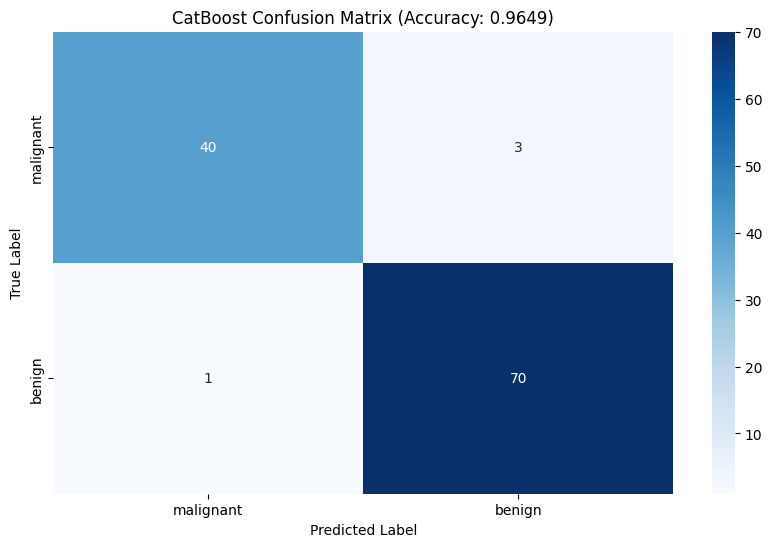

Final Test Accuracy: 0.9649


In [17]:
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the CatBoost Classifier
# iterations: number of trees, depth: depth of trees, verbose: log every 100 iterations
model = CatBoostClassifier(iterations=200,depth=5,learning_rate=0.1,verbose=100)
model.fit(X_train, y_train)

# 4. Predict and evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# 5. Plot the Confusion Matrix using Seaborn
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title(f'CatBoost Confusion Matrix (Accuracy: {acc:.4f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(f"Final Test Accuracy: {acc:.4f}")

Question 10: You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
● Data preprocessing & handling missing/categorical values
● Choice between AdaBoost, XGBoost, or CatBoost
● Hyperparameter tuning strategy
● Evaluation metrics you'd choose and why
● How the business would benefit from your model
(Include your Python code and output in the code box below.)

Building a pipeline for FinTech requires a balance between high predictive power and rigorous handling of data irregularities. Given the imbalance and mixed data types typical of loan datasets, here is the strategic approach.

1. Data Preprocessing & Handling Values

* Missing Values: Since we are using boosting, we can leverage native handling. For XGBoost, we leave them as NaN and let the model learn the default direction. For CatBoost, we can treat them as a "Minimum" or "Maximum" value or a separate category.

* Categorical Features: We will avoid manual One-Hot Encoding to prevent dimensionality explosion. We'll use CatBoost's native categorical support or XGBoost's enable_categorical=True.

2. The Choice: Why CatBoost?

For this specific scenario, CatBoost is the winner.

* Why not AdaBoost? It is too sensitive to outliers (common in transaction data) and doesn't handle categories natively.

* Why not XGBoost? While excellent, XGBoost requires more manual prep for categories and is easier to overfit on small, imbalanced datasets.

* CatBoost Advantage: Its Ordered Boosting prevents data leakage, and its handling of categorical "combinations" is perfect for spotting fraud/default patterns (e.g., combining Occupation + ZipCode).

3. Hyperparameter Tuning Strategy

We use RandomizedSearchCV over GridSearchCV to save time while covering more "parameter space."

* Target Params: learning_rate (keep it low, 0.01–0.1), depth (keep it shallow, 4–8, to prevent memorizing outliers), and l2_leaf_reg.

* Class Weights: Crucial for imbalance. We set auto_class_weights='Balanced' so the model pays more attention to the minority "Default" class.

4. Evaluation Metrics

* Primary Metric: PR-AUC (Precision-Recall Area Under Curve). In imbalanced loan data, ROC-AUC can be misleadingly high. PR-AUC focuses on the model's ability to find the defaults without flagging too many good customers.

* Secondary Metric: F1-Score or Recall. We want to minimize "False Negatives" (missing a default), as that is the most expensive mistake for a FinTech.

5. Business Benefit

* Lower Loss Ratios: By catching even 5% more defaults than a traditional scorecard, the company saves millions in capital.

* Automation: Faster approval times for "Low Risk" customers identified by the model with high confidence.

In [18]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

# 1. Create a dummy FinTech dataset for demonstration
data = {
    'income': np.random.randint(20000, 100000, 1000),
    'credit_score': np.random.randint(300, 850, 1000),
    'employment_type': np.random.choice(['Full-time', 'Part-time', 'Freelance'], 1000),
    'location': np.random.choice(['Urban', 'Rural', 'Suburban'], 1000),
    'default': np.random.choice([0, 1], 1000, p=[0.9, 0.1]) # Imbalanced
}
df = pd.DataFrame(data)

# 2. Define Features and Target
X = df.drop('default', axis=1)
y = df['default']
cat_features = ['employment_type', 'location']

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train CatBoost
# auto_class_weights handles the imbalance
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features,
    auto_class_weights='Balanced',
    verbose=100
)

model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n--- Model Evaluation ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC Score: {average_precision_score(y_test, y_proba):.4f}")

0:	learn: 0.6930998	total: 15.2ms	remaining: 7.58s
100:	learn: 0.6091779	total: 1.5s	remaining: 5.91s
200:	learn: 0.4177454	total: 3.68s	remaining: 5.48s
300:	learn: 0.2703427	total: 6.59s	remaining: 4.36s
400:	learn: 0.1911579	total: 9.17s	remaining: 2.26s
499:	learn: 0.1362982	total: 11.7s	remaining: 0us

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       179
           1       0.06      0.05      0.05        21

    accuracy                           0.81       200
   macro avg       0.47      0.48      0.47       200
weighted avg       0.80      0.81      0.81       200

ROC-AUC Score: 0.4608
PR-AUC Score: 0.0996
